<a href="https://colab.research.google.com/github/4Unknown-user/Micro-Project/blob/main/Micro_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== Original Shape === (180, 12)

Missing values per column:
Student ID           0
Name                 0
Gender               0
Age                  0
GPA                  0
Major                0
Interested Domain    0
Projects             0
Future Career        0
Python               0
SQL                  0
Java                 0
dtype: int64

Total missing values in dataset: 0
=== Dataset Overview ===
   Student ID           Name  Gender  Age  GPA             Major  \
0           1     John Smith    Male   21  3.5  Computer Science   
1           2  Alice Johnson  Female   20  3.2  Computer Science   
2           3   Robert Davis    Male   22  3.8  Computer Science   
3           4   Emily Wilson  Female   21  3.7  Computer Science   
4           5  Michael Brown    Male   23  3.4  Computer Science   

         Interested Domain             Projects                 Future Career  \
0  Artificial Intelligence  Chatbot Development   Machine Learning Researcher   
1             Data

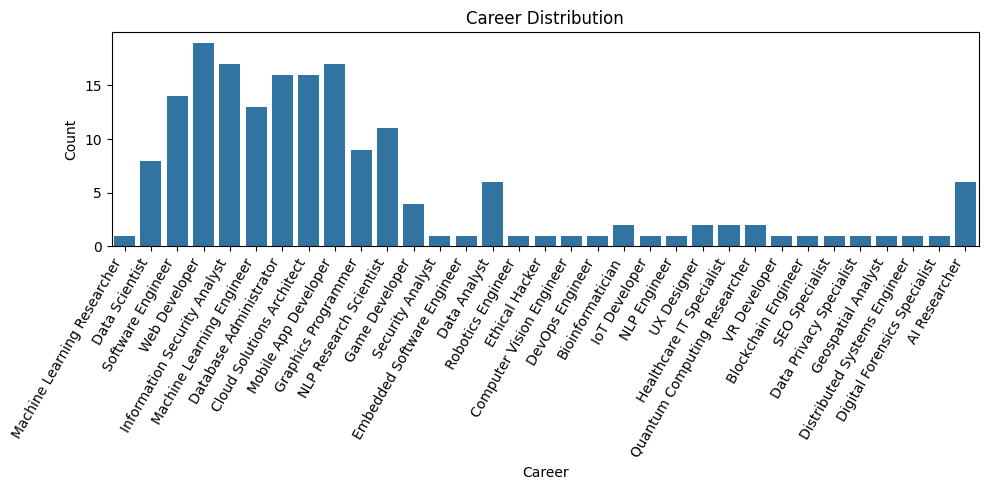

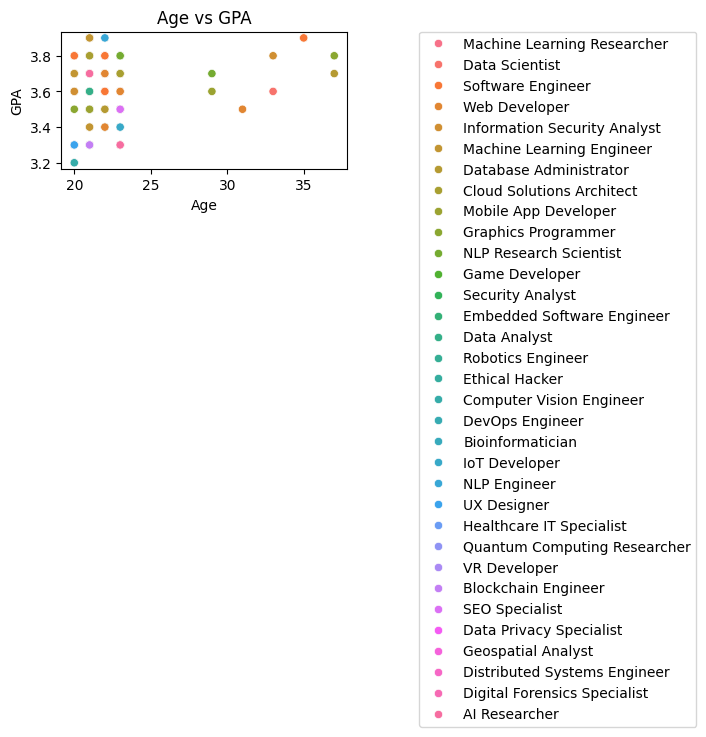

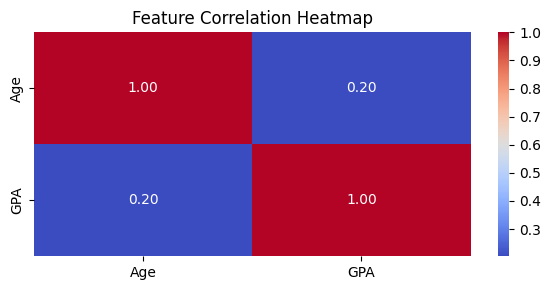

Class Weights: {0: np.float64(1.1637931034482758), 1: np.float64(4.655172413793103), 2: np.float64(4.655172413793103), 3: np.float64(0.3879310344827586), 4: np.float64(4.655172413793103), 5: np.float64(2.3275862068965516), 6: np.float64(0.5818965517241379), 7: np.float64(0.4231974921630094), 8: np.float64(4.655172413793103), 9: np.float64(4.655172413793103), 10: np.float64(4.655172413793103), 11: np.float64(4.655172413793103), 12: np.float64(1.5517241379310345), 13: np.float64(4.655172413793103), 14: np.float64(0.5818965517241379), 15: np.float64(4.655172413793103), 16: np.float64(0.3879310344827586), 17: np.float64(0.46551724137931033), 18: np.float64(4.655172413793103), 19: np.float64(0.33251231527093594), 20: np.float64(4.655172413793103), 21: np.float64(0.5172413793103449), 22: np.float64(4.655172413793103), 23: np.float64(4.655172413793103), 24: np.float64(4.655172413793103), 25: np.float64(0.46551724137931033), 26: np.float64(2.3275862068965516), 27: np.float64(4.655172413793103)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.0556 - loss: 9.7531 - val_accuracy: 0.0370 - val_loss: 3.7784
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.0093 - loss: 9.5259 - val_accuracy: 0.0741 - val_loss: 3.7307
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.0463 - loss: 8.7327 - val_accuracy: 0.1111 - val_loss: 3.6914
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.0926 - loss: 8.3571 - val_accuracy: 0.1111 - val_loss: 3.6547
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.1019 - loss: 8.1883 - val_accuracy: 0.1481 - val_loss: 3.6236
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.1111 - loss: 7.6989 - val_accuracy: 0.1852 - val_loss: 3.5930
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.2037 - loss: 7.4988 - val_accuracy: 0.2222 - val_loss: 3.5630
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.1852 - loss: 7.3548 - val_accuracy: 0.2222 - val_loss: 3.5335
Epoc

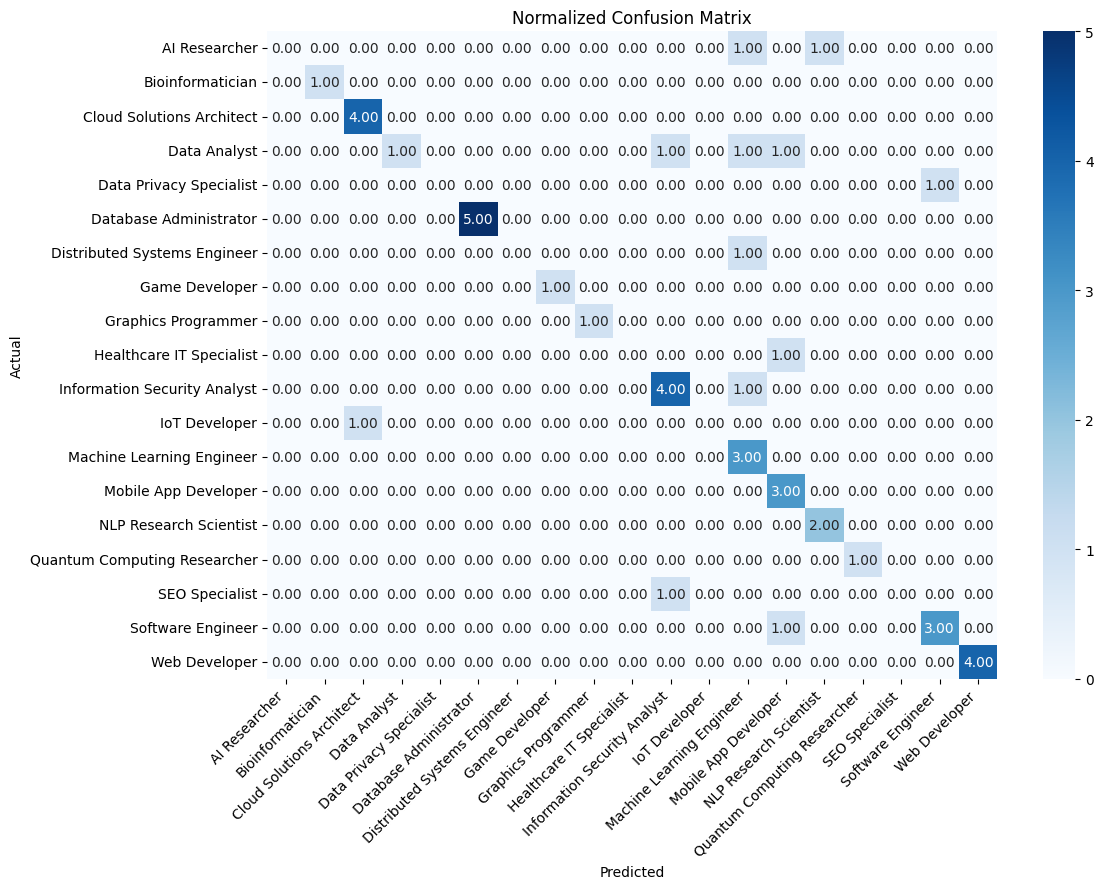

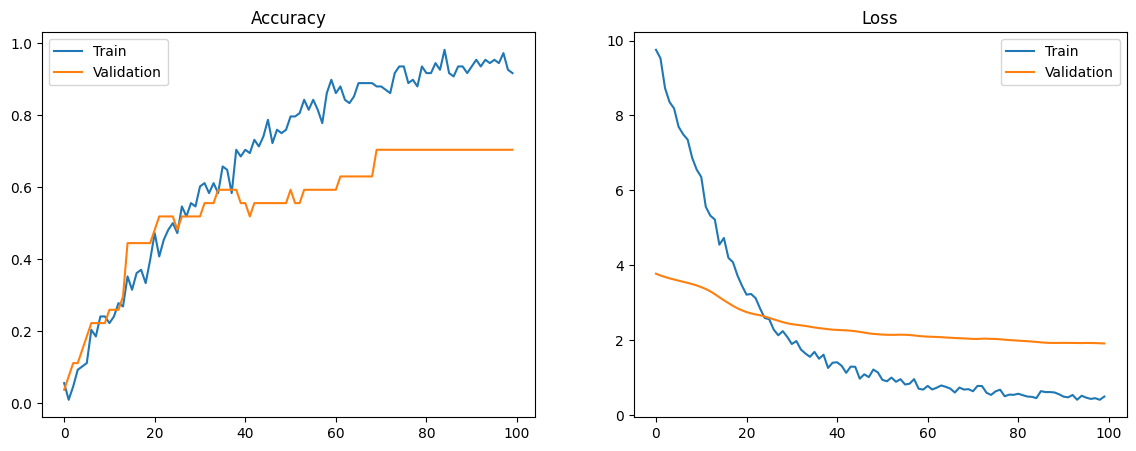

Model saved!

Final Accuracy: 73.33%


In [ ]:
# Step 1 & 2 — Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
tf.random.set_seed(42)
np.random.seed(42)
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score,recall_score, f1_score, confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.utils.class_weight import compute_class_weight

# Step 3 — Load Dataset
df = pd.read_csv('cs_students.csv')

print("=== Original Shape ===", df.shape)

# Handle Missing Values (instead of dropping)

# Numerical columns → fill with mean
for col in df.select_dtypes(include=np.number):
    df[col] = df[col].fillna(df[col].mean())

# Categorical columns → fill with most frequent (mode)
for col in df.select_dtypes(exclude=np.number):
    df[col] = df[col].fillna(df[col].mode()[0])

# Count missing values BEFORE handling
missing_values = df.isnull().sum()
total_missing = missing_values.sum()

print("\nMissing values per column:")
print(missing_values)

print(f"\nTotal missing values in dataset: {total_missing}")
print("=== Dataset Overview ===")
print(df.head())
print("Shape:", df.shape)

# Step 4 — Feature Selection + Visualization

# Drop unnecessary column
columns_to_drop = ['Student ID']
df.drop(columns=[col for col in columns_to_drop if col in df.columns], inplace=True)

# Separate features and target
X = df.drop('Future Career', axis=1)
y = df['Future Career']


# Bar Chart — Career Distribution (IMPORTANT)
plt.figure(figsize=(10,5))
sns.countplot(x='Future Career', data=df)
plt.xticks(rotation=60, ha='right')
plt.title("Career Distribution")
plt.xlabel("Career")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))

num_cols = df.select_dtypes(include=np.number).columns

ax = sns.scatterplot(
    x=num_cols[0],
    y=num_cols[1],
    hue='Future Career',
    data=df
)

plt.title(f"{num_cols[0]} vs {num_cols[1]}")

# Move legend completely outside
plt.legend(
    bbox_to_anchor=(1.25, 1),
    loc='upper left',
    borderaxespad=0
)

plt.tight_layout()
plt.show()


# Correlation Heatmap
plt.figure(figsize=(6,3))
sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

# Step 5 — Train-Test Split

from sklearn.preprocessing import StandardScaler

# Encode target labels
label_encoder = LabelEncoder()
label_encoder.fit(y)

# Split dataset
X_train, X_test, y_train_raw, y_test_raw = train_test_split(
    X, y, test_size=0.25, random_state=36
)

# One-hot encoding (AFTER split to avoid leakage)
X_train = pd.get_dummies(X_train)
X_test  = pd.get_dummies(X_test)

# Ensure same columns in train & test
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

#  Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)   # fit only on training data
X_test  = scaler.transform(X_test)        # transform test data

# Encode target variable
y_train = to_categorical(label_encoder.transform(y_train_raw))
y_test  = to_categorical(label_encoder.transform(y_test_raw))

# Step 6 — ANN Model
num_features = X_train.shape[1]
num_classes  = y_train.shape[1]

model = Sequential()
model.add(Dense(128, activation='relu', input_dim=num_features,
                kernel_regularizer=l2(0.001)))
model.add(Dropout(0.4))

model.add(Dense(64, activation='relu',
                kernel_regularizer=l2(0.001)))
model.add(Dropout(0.3))

model.add(Dense(32, activation='relu',
                kernel_regularizer=l2(0.001)))

model.add(Dense(num_classes, activation='softmax'))

# Step 7 — Train

# Convert one-hot encoded y_train to label format
y_train_labels = np.argmax(y_train, axis=1)

# Compute class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)

# Convert to dictionary (required by Keras)
class_weights_dict = dict(enumerate(class_weights))

print("Class Weights:", class_weights_dict)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train model with class weights
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    class_weight=class_weights_dict,
    verbose=1
)

# Step 8 — Prediction
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

# Step 9 — Metrics
accuracy  = accuracy_score(y_test_classes, y_pred_classes)
precision = precision_score(y_test_classes, y_pred_classes, average='weighted', zero_division=0)
recall    = recall_score(y_test_classes, y_pred_classes, average='weighted', zero_division=0)
f1        = f1_score(y_test_classes, y_pred_classes, average='weighted', zero_division=0)

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# NEW: Train vs Test Evaluation
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print(f"\nTrain Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# Fix — use classes from BOTH y_test and y_pred
unique_classes = np.union1d(y_test_classes, y_pred_classes)
target_names = label_encoder.classes_[unique_classes]

print("\nClassification Report:")
print(classification_report(y_test_classes, y_pred_classes,
                            labels=unique_classes,
                            target_names=target_names,
                            zero_division=0))

# Step 10 — Confusion Matrix
cm = confusion_matrix(y_test_classes, y_pred_classes, labels=unique_classes)

plt.figure(figsize=(12, 9))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names)
plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Step 11 — Training Graph
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title("Loss")
plt.legend()

plt.show()

# Save Model
model.save("career_model.keras")
print("Model saved!")

print(f"\nFinal Accuracy: {accuracy*100:.2f}%")